# Alpine Ontario Ski Climate Impact Report

**Interactive, reproducible notebook version**

> **To run the full report:** in VS Code, open this `.ipynb` file and choose **Run All**.

This notebook contains the written report, assumptions, analysis code, tables, figures, interpretations, and appendices from the supplied *Alpine Ontario Ski Climate Impact Report*. The analysis uses the bundled processed climate dataset so it can be run locally without Google Colab or Google Cloud credentials.

---

## Table of Contents

1. Executive Summary
2. Sources of Data
3. Assumptions
4. Future Climate Trends
5. Interpretation of Future Climate Trends
6. January Climate Analysis
7. Key Takeaways for Operations
8. Operational Conditions: Good and Bad Days
9. Interpretation of Results
10. Appendices
   - Appendix A: Full List of Climate Models Used
   - Appendix B: SSP Scenario Details
   - Appendix C: Variables Explained

In [2]:
# ============================================================
# PROJECT SETUP
# ============================================================
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Make the repository root importable when this notebook is run from VS Code.
ROOT = Path.cwd()
if not (ROOT / "data" / "climate_spatial_means_full.parquet").exists():
    ROOT = Path.cwd().parent

DATA_FILE = ROOT / "data" / "climate_spatial_means_full.parquet"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

from src import config
from src.analysis import load_data, plot_future_trends, january_analysis, good_bad_days

# Default assumptions from the original report.
SCENARIO = "ssp585"
START_YEAR = 2025
END_YEAR = 2100

print("Repository:", ROOT)
print("Data file:", DATA_FILE)
print("Scenario:", SCENARIO)
print("Study period:", START_YEAR, "to", END_YEAR)

Repository: c:\Users\trent\Desktop\alpine-ontario-ski-climate-impact
Data file: c:\Users\trent\Desktop\alpine-ontario-ski-climate-impact\data\climate_spatial_means_full.parquet
Scenario: ssp585
Study period: 2025 to 2100


# Executive Summary

This report evaluates how projected climate change may affect winter operations at a ski facility over the next several decades. It is designed as a self-contained, repeatable analysis that can be rerun with different locations, time horizons, climate scenarios, and operational definitions as assumptions change.

Using a large ensemble of global climate models from the CMIP6 framework, this report examines future trends in temperature, precipitation, humidity, and wind; key drivers of snowmaking. Rather than relying on a single forecast, this analysis presents 35 models, reflecting uncertainty across models and emission futures.

Two operationally relevant classifications are central to this analysis:

- **Good days:** Days suitable for snowmaking, defined using thresholds for temperature and other variables.
- **Bad days:** Days where temperature and/or precipitation are high enough to negatively impact snow quality, surface conditions, or guest experience.

These definitions are applied consistently across all climate models to produce a timeseries of good and bad days. The resulting trends provide a clear picture of how the frequency, variability, and reliability of operationally critical days may change over the study horizon.

### Key outputs

- Time-series plots showing projected changes in climate variables across models
- Summary tables comparing early-period and late-period conditions
- Annual counts and long-term trends in good and bad operational days

The intent is not to produce a single deterministic forecast, but to support risk-aware operational planning. By quantifying potential future trends, this report helps identify where current operating assumptions may be obsolete in the future and where adaptation strategies may become increasingly important.

# Sources of Data

## Climate Model Data

All climate projections in this report are sourced from the **NASA Earth Exchange Global Downscaled Projections (NEX-GDDP-CMIP6)** dataset, hosted by NASA's Center for Climate Simulation.

The dataset provides:

- Daily climate variables
- Spatially downscaled outputs suitable for regional-specific analysis
- Coverage from 1950 through 2100; this study focuses on the period 2000–2100
- Multiple Shared Socioeconomic Pathways (SSPs) representing alternative emission futures

Data was accessed via the NASA THREDDS service:

https://ds.nccs.nasa.gov/thredds/catalog/AMES/NEX/GDDP-CMIP6/catalog.html

## Climate Model Scenarios

The analysis uses a broad ensemble of CMIP6 global climate models, including:

- ACCESS-CM2
- EC-Earth3
- NorESM2

For the full list, see **Appendix A**.

Multiple emission scenarios are evaluated:

- Historical
- SSP126
- SSP245
- SSP370
- SSP585

For an explanation of the scenarios, see **Appendix B**.

This multi-model and multi-SSP dataset accounts for uncertainties in future socioeconomic pathways and structural differences between climate models.

## Variables Used

Daily climate variables analyzed include:

- `hurs` — Relative Humidity (near surface)
- `huss` — Specific Humidity
- `pr` — Precipitation
- `rlds` — Downward Longwave Radiation
- `rsds` — Downward Shortwave Radiation
- `sfcWind` — Surface Wind Speed
- `tas` — Average Surface Air Temperature
- `tasmax` — Daily Maximum Temperature
- `tasmin` — Daily Minimum Temperature

See **Appendix C** for detailed variable explanations.

## Data Processing

Raw NetCDF files were downloaded in 5-year increments and processed using custom Python workflows. Processed outputs are stored in a Parquet file to ensure:

- Fast re-analysis and plotting
- Reproducibility
- Easy modification of assumptions without re-downloading raw data

## Limitations

- **Microclimates are not resolved:** local effects such as forest cover, slope orientation, snowmaking and nearby water bodies are not explicitly modeled.
- **Long-term focus:** The analysis is intended to assess long-term trends and risks. It is not suitable for short-term operational planning or season-to-season forecasting.
- **Threshold-based definitions:** “Good days” and “bad days” are defined using fixed thresholds. Small changes in these thresholds can change results.
- **Precipitation phase uncertainty:** Precipitation is not explicitly classified as rain or snow; impacts are inferred from temperature thresholds.

### Additional Notes

Portions of this report’s structure and drafting were developed with the assistance of AI tooling (Microsoft Copilot and ChatGPT). All data processing, assumptions, analysis, and conclusions have been reviewed and validated.

# Assumptions

The default assumptions below reproduce the supplied report's operating definitions.

## Location assumptions — default Caledon

- Caledon Ski Club: `43.880, 43.850, -79.950, -79.900`
- Blue Mountain: `44.525, 44.475, -80.350, -80.280`
- Osler Bluff: `44.535, 44.505, -80.325, -80.275`

The default location is the Caledon bounding box:

- Latitude north: `43.880`
- Latitude south: `43.850`
- Longitude west: `-79.950`
- Longitude east: `-79.900`

The analysis uses the midpoint of this bounding box as the derived location.

## Year range

- Default scenario: **SSP585**
- Start year: **2025**
- End year: **2100**

## Good-day assumptions

A good day is defined using all applicable thresholds below:

- `tas <= 265 K` — cold enough for snowmaking
- `hurs <= 85%` — dry enough to improve wet-bulb efficiency
- `pr <= 1 mm/day` — no meaningful precipitation
- Study period: 2000–2100

Additional variables are available but not used by default:

`sfcWind`, `rsds`, `rlds`, `huss`, `tasmax`, `tasmin`.

## Bad-day assumptions

A bad day is defined using:

- `tas >= 283 K` — too warm for snowmaking or snow preservation
- `pr >= 5 mm/day` — rain or heavy mixed precipitation
- `hurs >= 90%` — high humidity can worsen melt and surface conditions
- Study period: 2000–2100

## Snowmaking variables

The original report specifies:

```text
hurs, pr, tasmax
```

for the main snowmaking-related climate-variable analysis.

In [3]:
# Display the active assumptions in a compact table.
assumptions = pd.DataFrame([
    ["Scenario", SCENARIO],
    ["Start year", START_YEAR],
    ["End year", END_YEAR],
    ["Latitude north", config.LAT_N],
    ["Latitude south", config.LAT_S],
    ["Longitude west", config.LON_W],
    ["Longitude east", config.LON_E],
    ["Good day: tas maximum (K)", config.GOOD_DAY["tas"]["max"]],
    ["Good day: relative humidity maximum (%)", config.GOOD_DAY["hurs"]["max"]],
    ["Good day: precipitation maximum (mm/day)", 1.0],
    ["Bad day: tas minimum (K)", config.BAD_DAY["tas"]["min"]],
    ["Bad day: relative humidity minimum (%)", config.BAD_DAY["hurs"]["min"]],
    ["Bad day: precipitation minimum (mm/day)", 5.0],
], columns=["Assumption", "Value"])
display(assumptions)

,Assumption,Value
0,Scenario,ssp585
1,Start year,2025
2,End year,2100
3,Latitude north,43.88
4,Latitude south,43.85
5,Longitude west,-79.95
6,Longitude east,-79.9
7,Good day: tas maximum (K),265.0
8,Good day: relative humidity maximum (%),85.0
9,Good day: precipitation maximum (mm/day),1.0


# Future Climate Trends

## Purpose of This Section

This section summarizes projected changes in key climate variables relevant to ski operations over the study horizon. Projections are derived from a suite of global climate models (GCMs), producing a family of plausible future trajectories rather than a single deterministic outcome. This ensemble approach captures uncertainty arising from both model structure and internal climate variability.

The analysis focuses on variables most directly affecting winter operations: near-surface air temperature, total precipitation, and additional atmospheric indicators where relevant.

Results are presented as time-series plots showing individual model projections alongside ensemble statistics. A summary table later in the report compares January conditions between the first and last decades of the study horizon, including ensemble means and the 5–95% inter-model range.

Loaded 1,432,887 rows.
Models represented: 29
Variables represented: hurs, huss, pr, rlds, rsds, sfcWind, tas, tasmax, tasmin


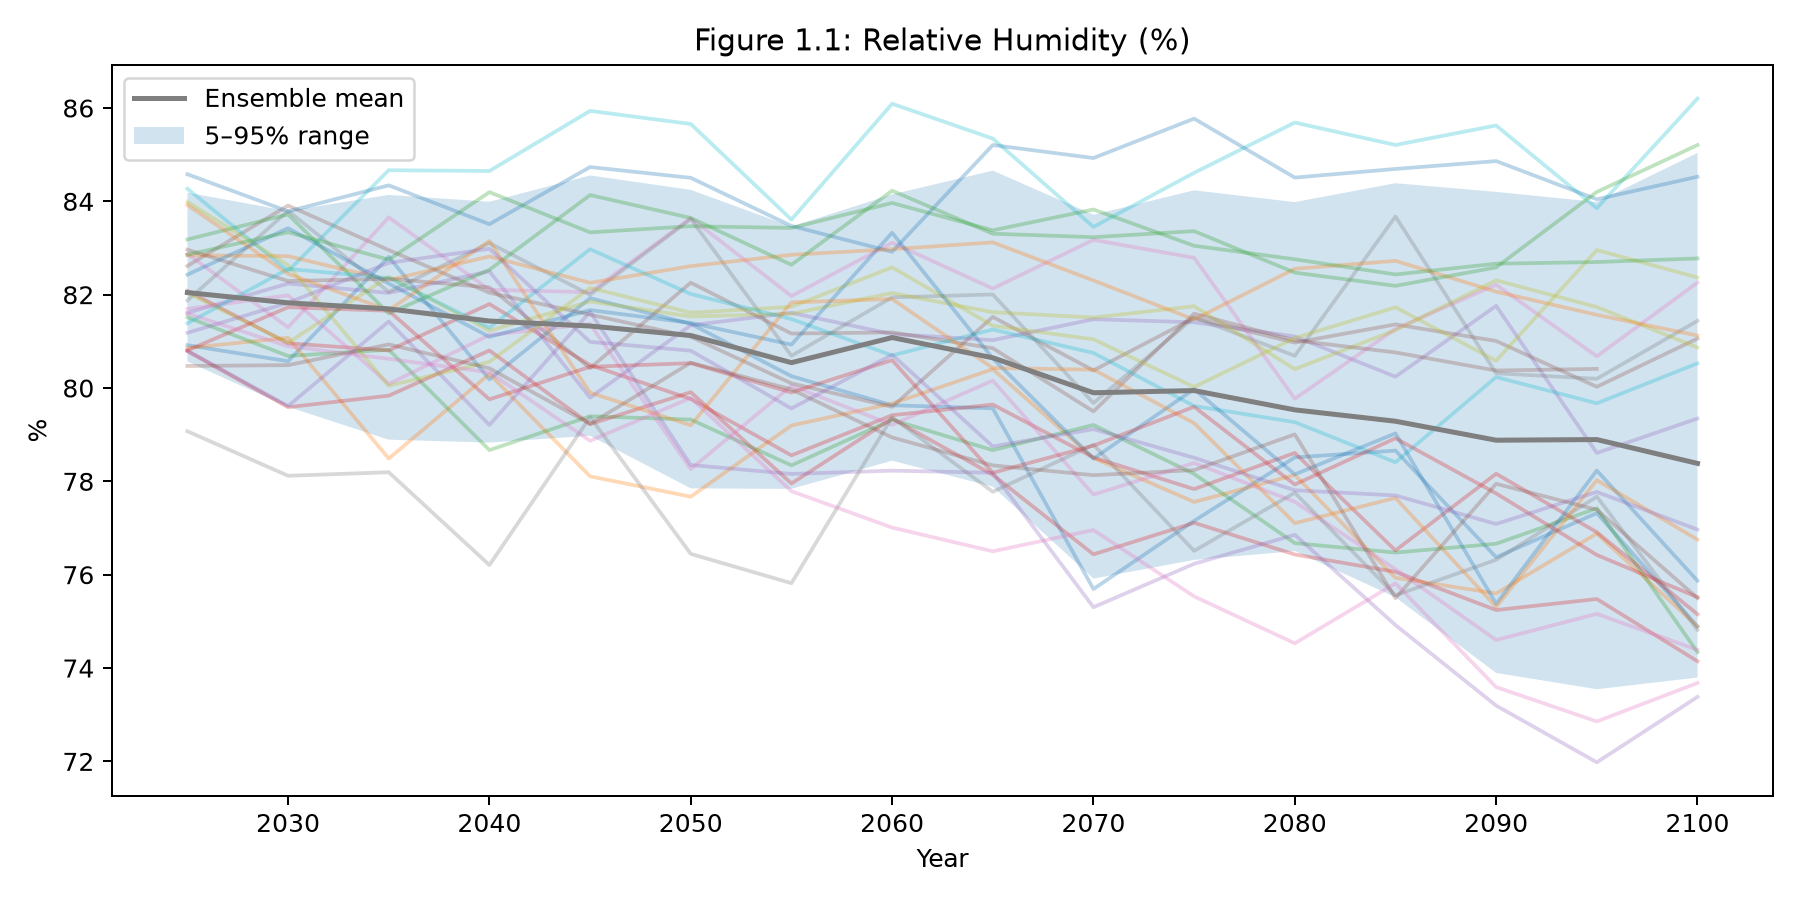

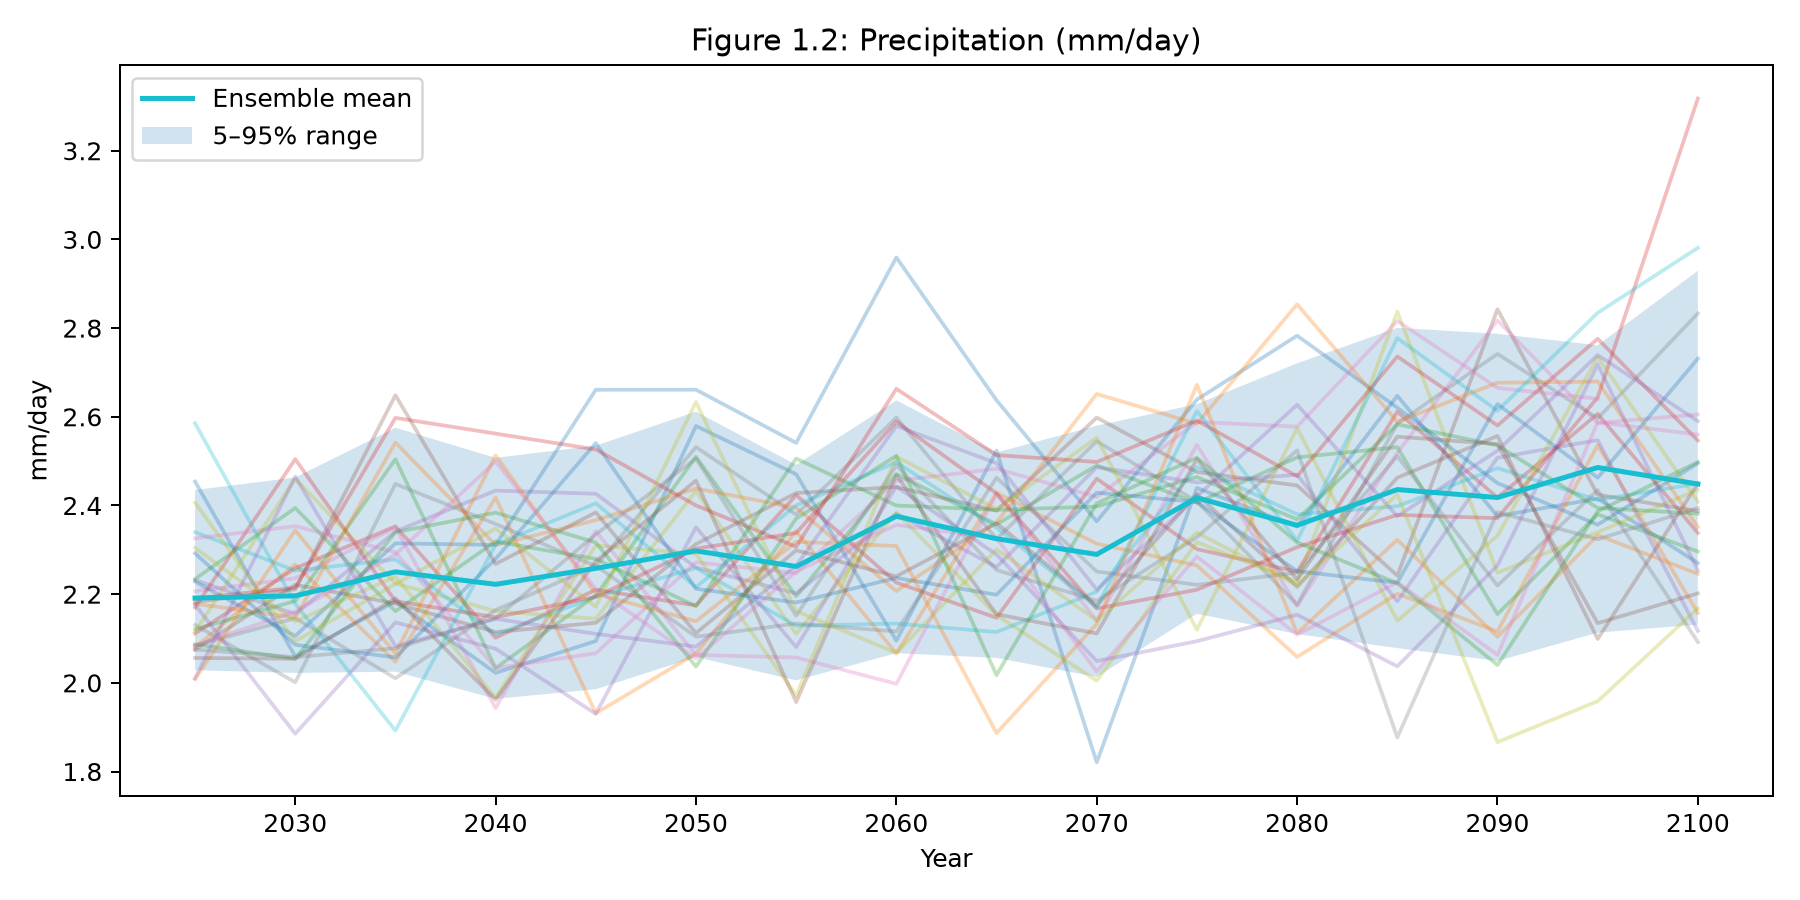

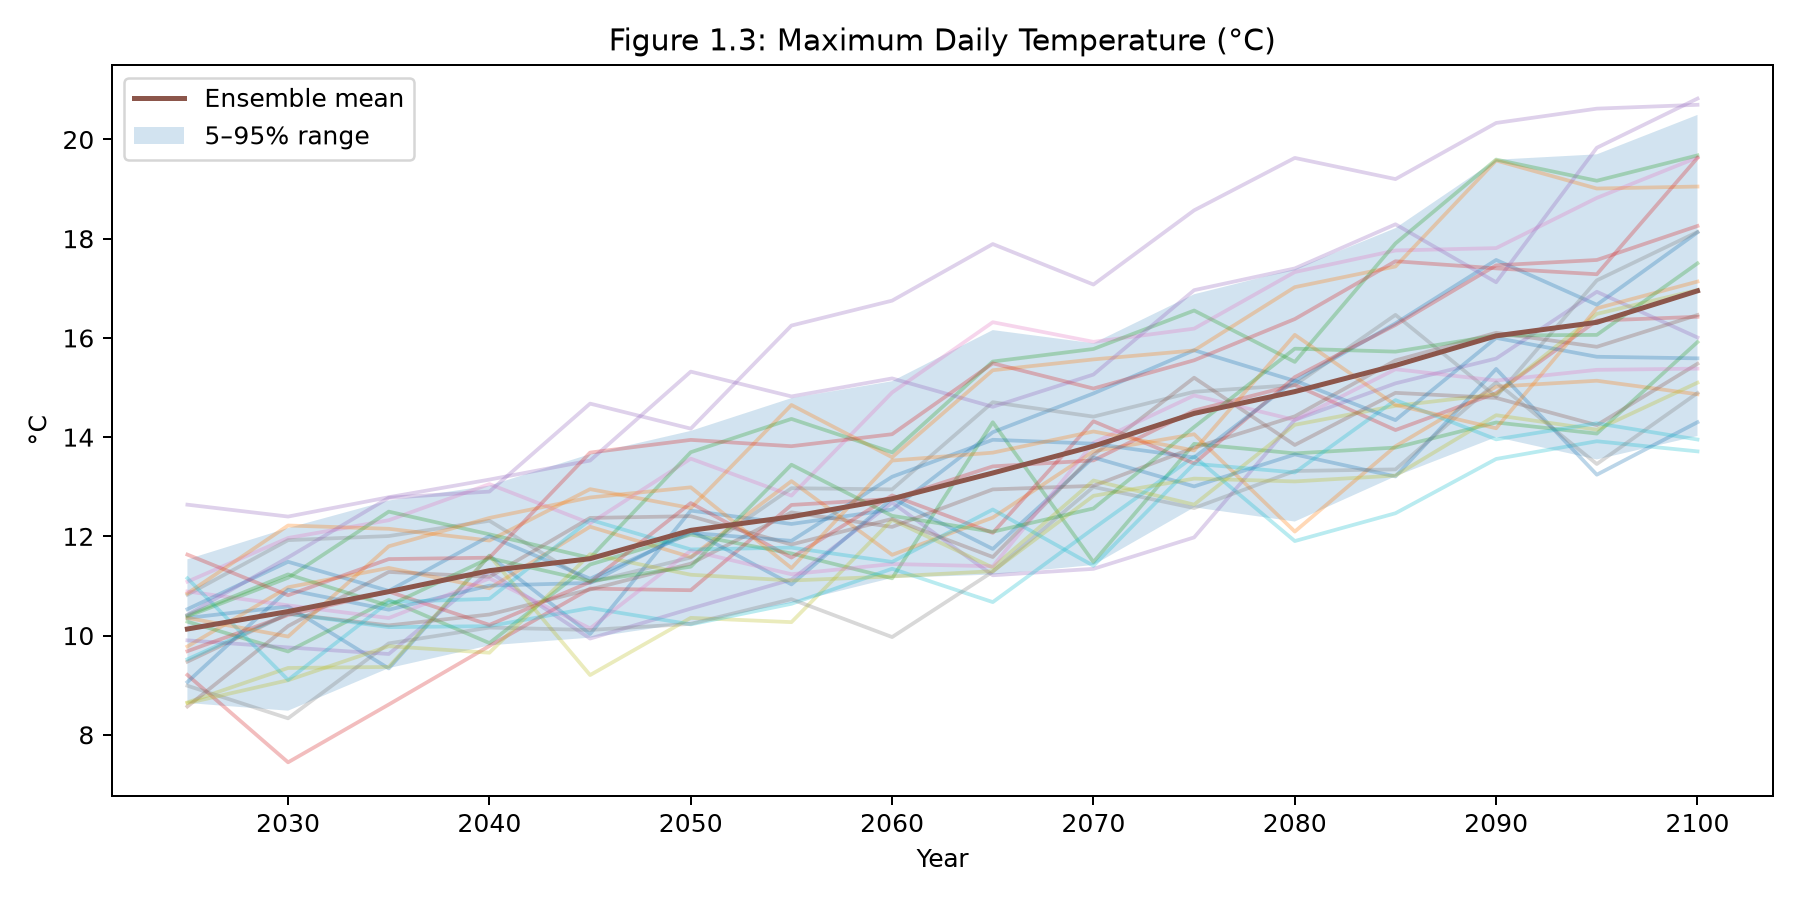

In [4]:
# Load the filtered dataset for the selected scenario and study period.
df = load_data(DATA_FILE, SCENARIO, START_YEAR, END_YEAR)

print(f"Loaded {len(df):,} rows.")
print(f"Models represented: {df['model'].nunique()}")
print(f"Variables represented: {', '.join(sorted(df['variable'].unique()))}")

# Generate Figures 1.1–1.3 and save them to outputs/.
plot_future_trends(df, OUTPUT_DIR, config.TREND_VARIABLES)

for var in config.TREND_VARIABLES:
    image_path = OUTPUT_DIR / f"future_climate_{var}.png"
    if image_path.exists():
        display(Image(filename=str(image_path)))

## Interpretation of Future Climate Trends

The figures above present projected trajectories for the climate variables specified in the `TREND_VARIABLES` list within the assumptions section. Across all variables, a wide range of model outcomes is observed, reflecting differing representations of climate processes and internal variability.

While individual models exhibit distinct patterns, the ensemble mean highlights clear directional trends over time. A notable feature across the variables is that the spread between models can increase as the study horizon progresses, indicating growing uncertainty in future conditions. This widening range reflects divergence in long-term climate responses and underscores the importance of considering a range of possible outcomes rather than relying on a single projection.

Relative humidity exhibits a particularly wide spread and less consistent behavior across models, indicating greater uncertainty in that variable. Despite this uncertainty, the overall ensemble trends provide useful information for operational planning.

# January Climate Analysis

The January analysis focuses on two variables:

- **January mean air temperature**
- **January total precipitation**

The original report converts temperature from Kelvin to Celsius and precipitation from kg m⁻² s⁻¹ to an approximate January total in millimetres using a 30-day month.

The analysis compares the first and last decades of the selected study horizon and reports the ensemble mean, absolute change, and 5–95% inter-model range for the last decade.

,Variable,First Decade Mean,Last Decade Mean,Absolute Change,95% CI (Last Decade)
0,January Mean Air Temperature,-12.600197,-3.857493,8.742704,-10.88 to 3.37
1,January Total Precipitation,45.798557,58.533932,12.735374,7.71 to 169.64


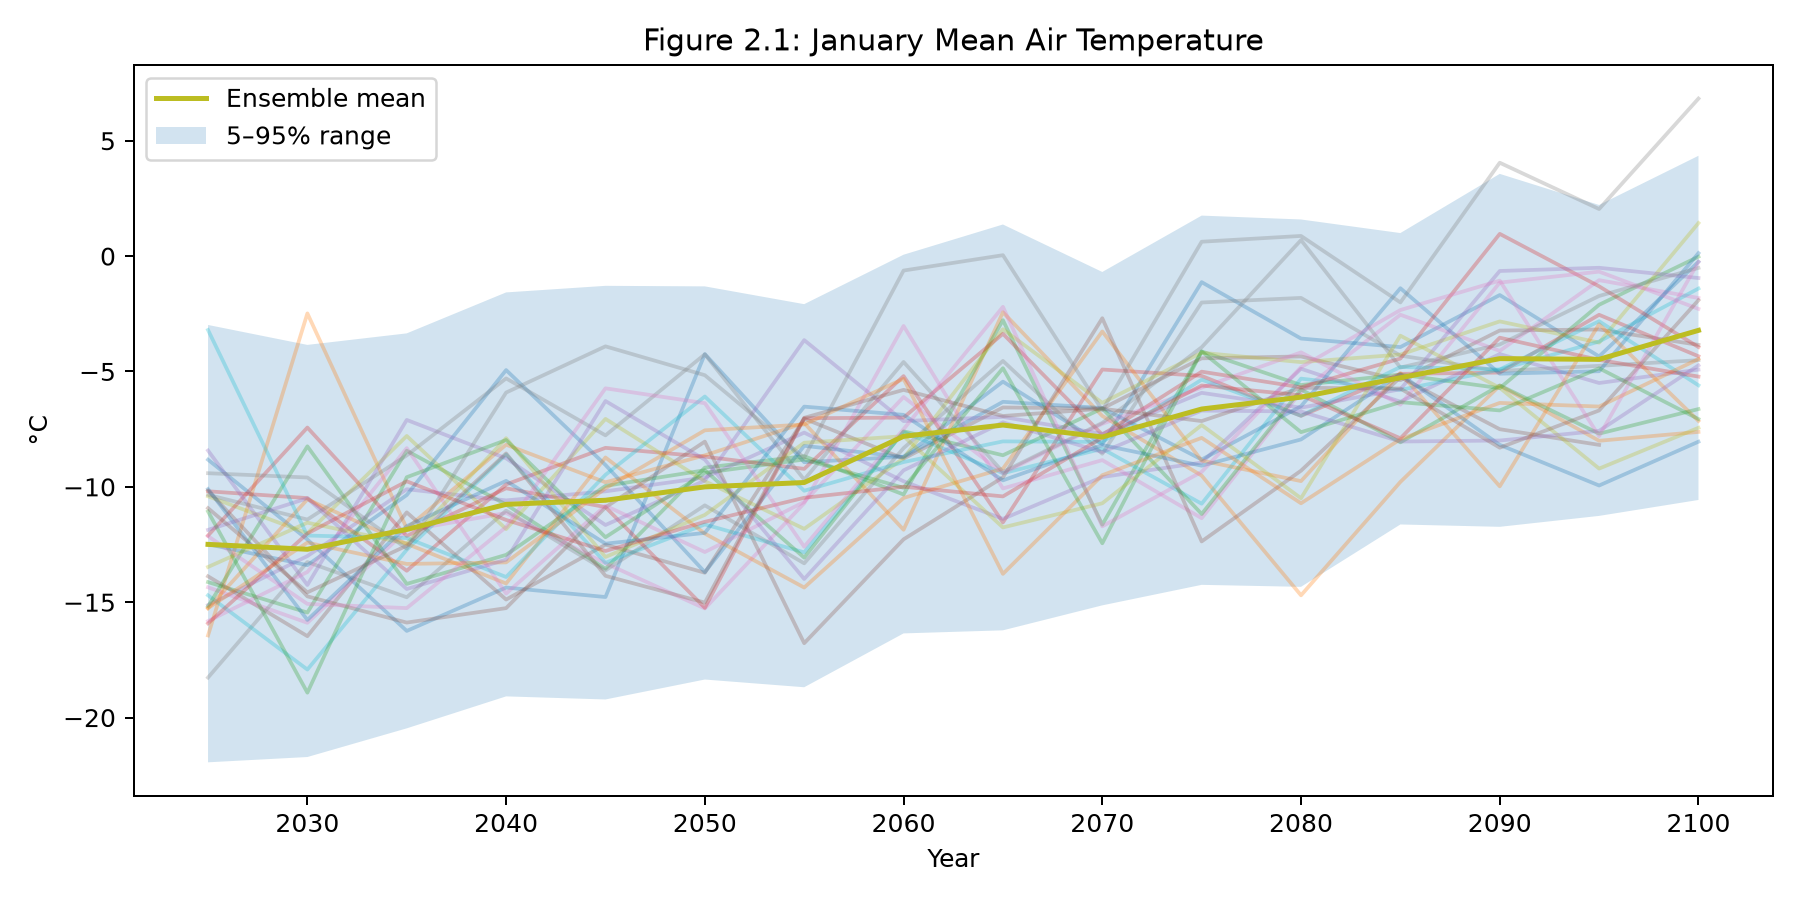

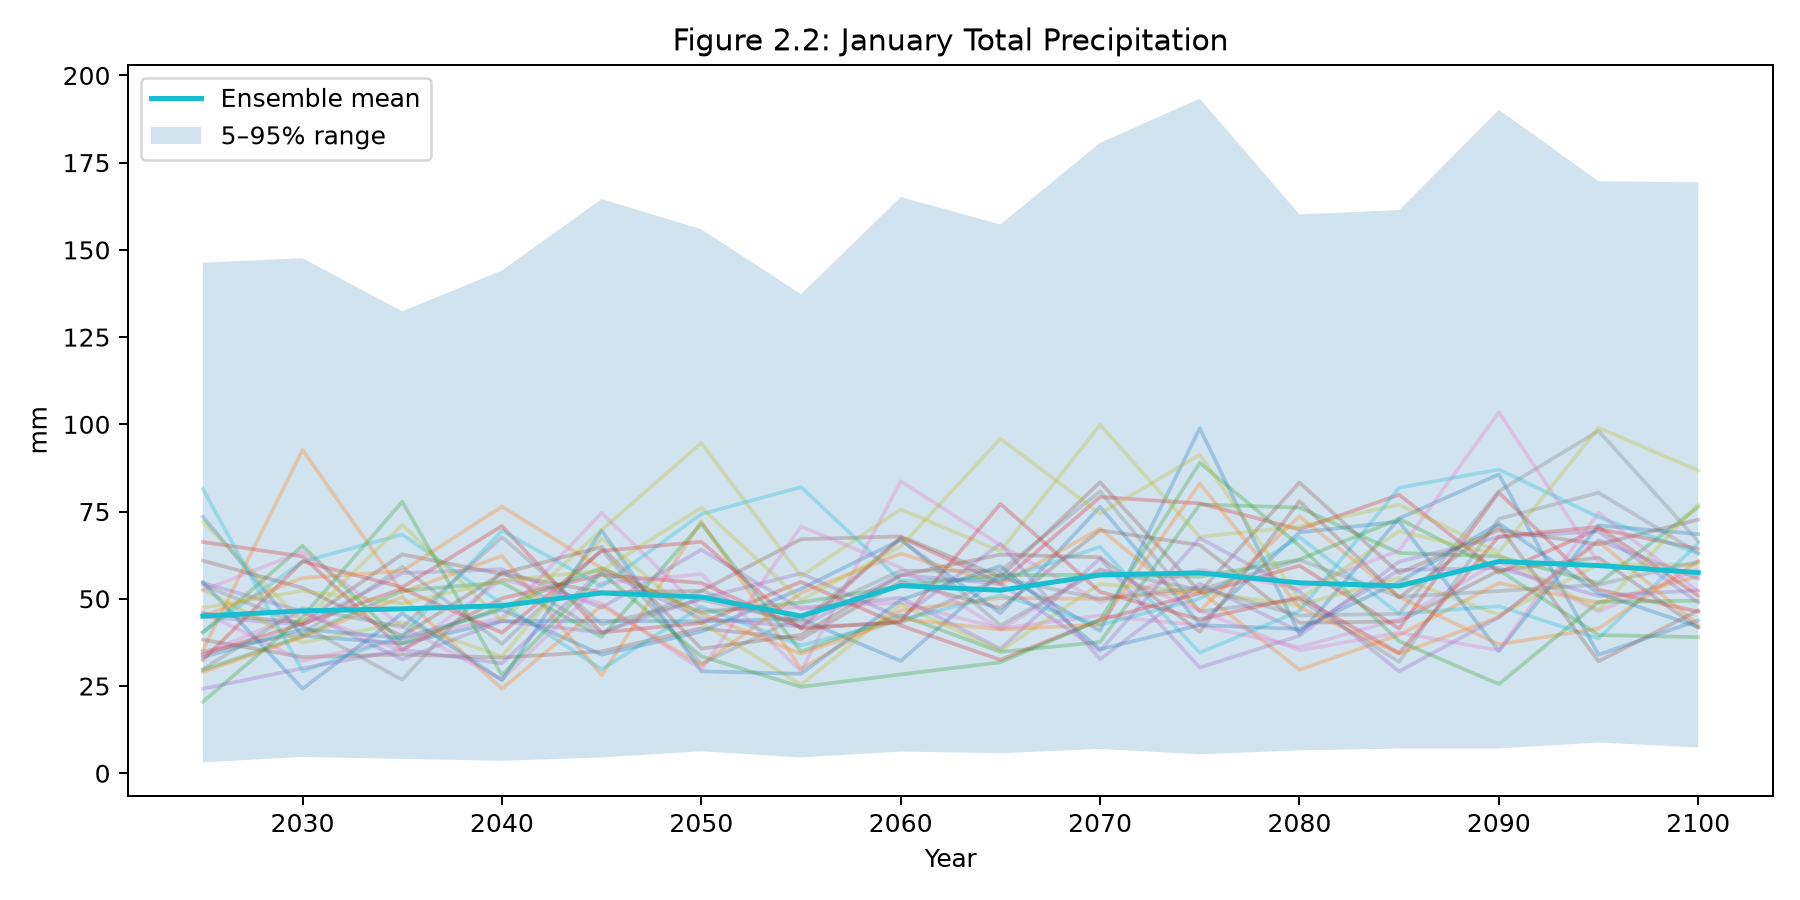

In [5]:
# Run the January analysis and display its summary table and figures.
january_summary = january_analysis(df, OUTPUT_DIR)
display(january_summary)

for var in ["tas", "pr"]:
    image_path = OUTPUT_DIR / f"january_{var}.png"
    if image_path.exists():
        display(Image(filename=str(image_path)))

**Table 2.2.** Summary of January climate conditions comparing the first and last decades of the study horizon. Values represent ensemble means across climate models, with uncertainty expressed as the 5–95% inter-model range. These values summarize the trends illustrated in Figures 2.1 and 2.2.

## Interpretation of January Climate Trends

All climate models project continued winter warming over the study horizon, with January temperatures increasing steadily across the ensemble. While the magnitude of warming varies by model, the direction of change is consistent, indicating high confidence in warmer winter conditions relative to the early part of the study period.

January total precipitation shows modest increases across most models; however, greater precipitation does not imply improved snow conditions. As temperatures rise, an increasing fraction of winter precipitation is expected to fall as rain rather than snow, particularly in marginal temperature regimes.

Model agreement is strongest for temperature trends, where uncertainty is relatively narrower, reinforcing confidence in continued warming. Precipitation projections exhibit greater spread, reflecting higher uncertainty in how moisture availability will change.

Together, these results indicate that temperature-driven impacts on snow reliability are robust, while precipitation-related impacts remain more uncertain but operationally significant.

# Key Takeaways for Operations

- Winter warming is robust across the model ensemble, with strong agreement on the direction of change.
- Temperature, rather than precipitation alone, is a dominant limiting factor for future snow reliability.
- Even where precipitation increases, rising temperatures reduce the likelihood that it falls as snow.
- Planning based solely on historical winter conditions becomes increasingly unreliable over time.

# Operational Conditions: Good and Bad Days

## Purpose of This Section

This section translates projected climate conditions into operationally meaningful days by applying predefined **“good day”** and **“bad day”** criteria to daily climate data.

The result is a year-by-year count of days that support or hinder operations across multiple climate models.

This is the bridge between climate data and decisions.

,Metric,Early period (avg),Late period (avg)
0,Good days,24.87931,4.532020
1,Bad days,2.87931,3.599754


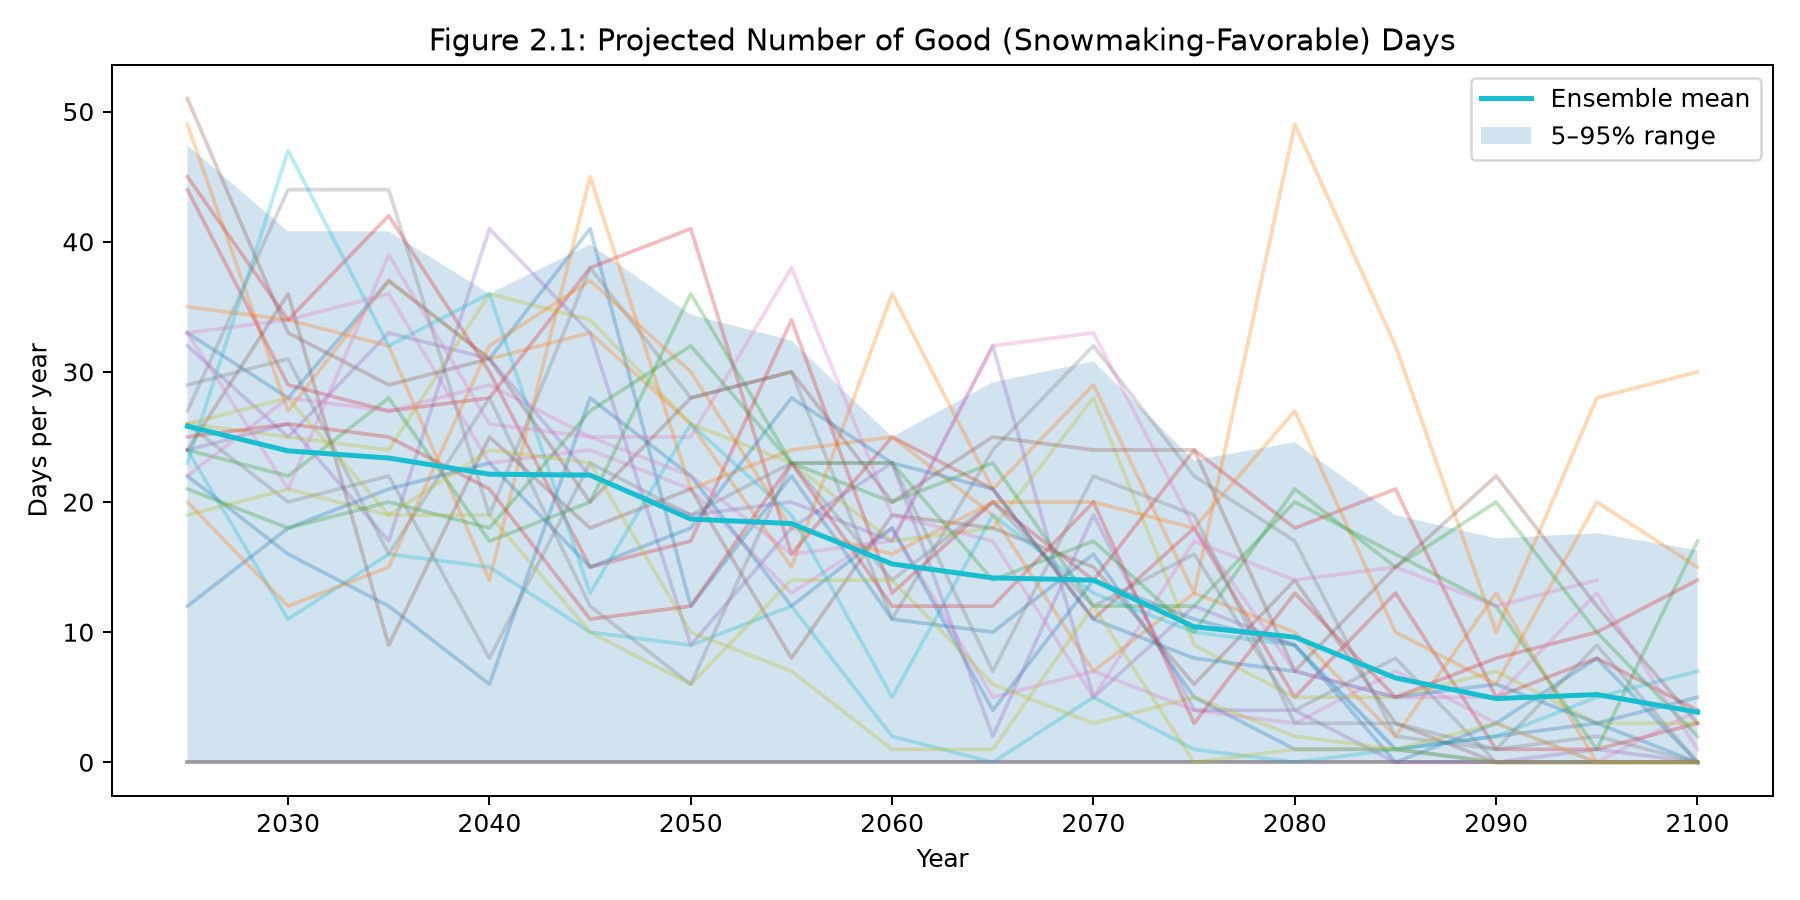

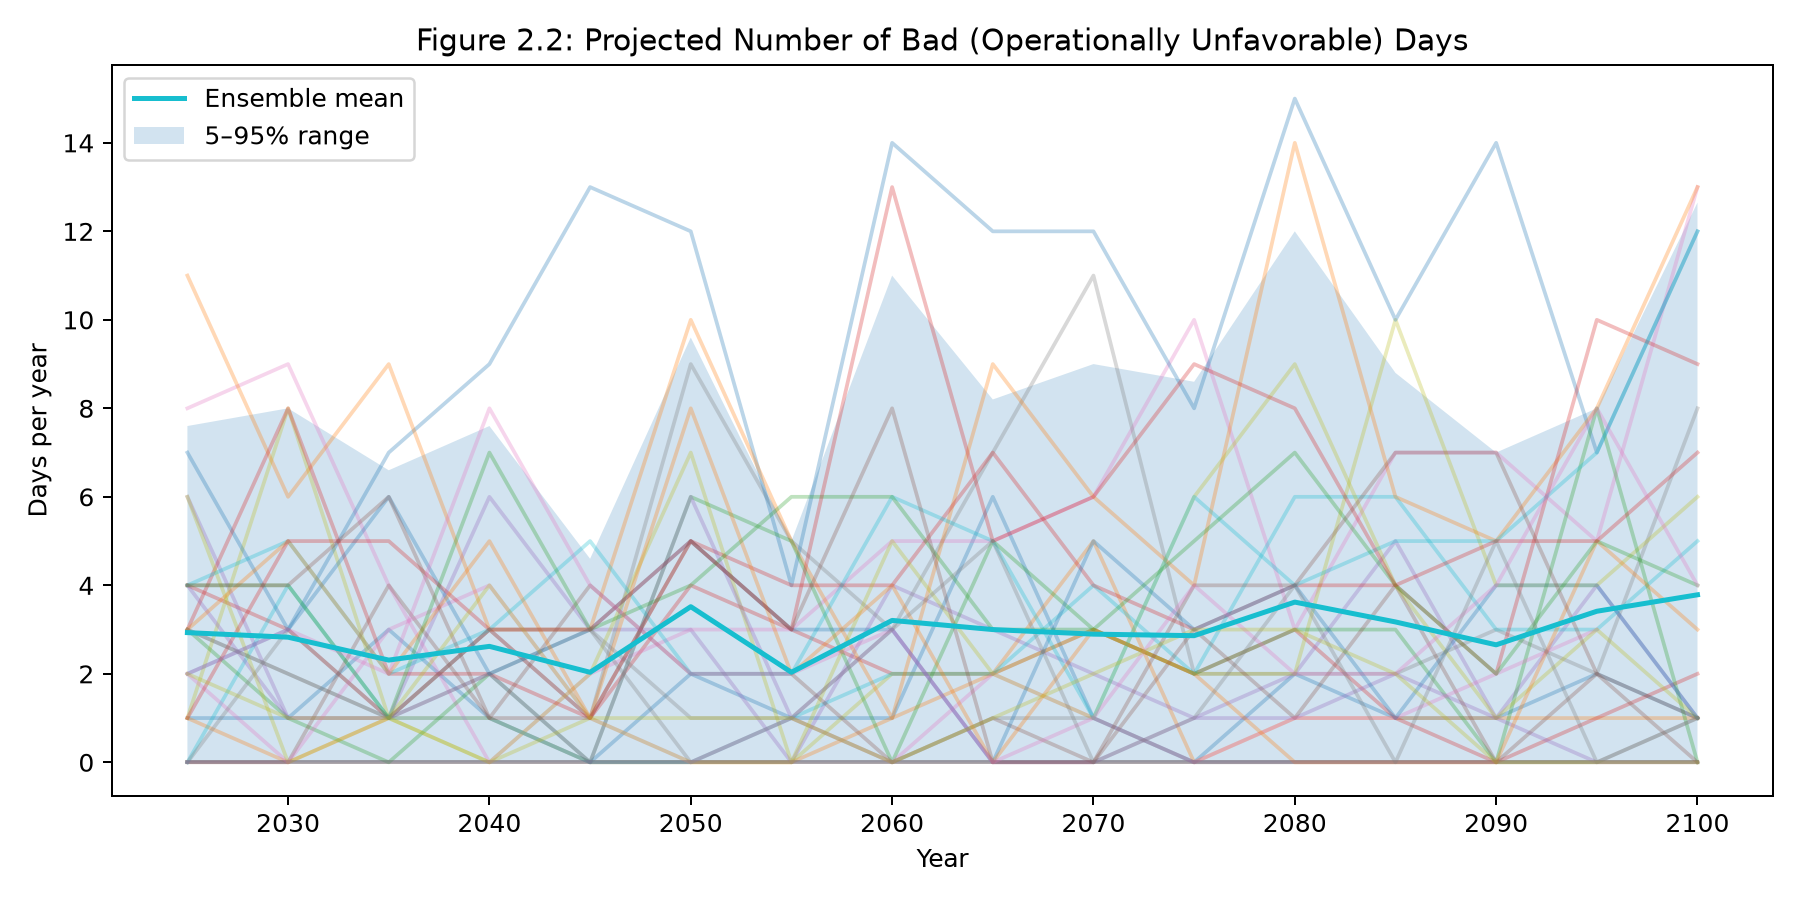

In [6]:
# Apply the original threshold definitions to daily data.
df_days, good_bad_summary = good_bad_days(df, OUTPUT_DIR)

display(good_bad_summary)

# Display the two operational figures.
for filename in ["good_days.png", "bad_days.png"]:
    image_path = OUTPUT_DIR / filename
    if image_path.exists():
        display(Image(filename=str(image_path)))

## Interactive Model/Year Explorer

The original report included an interactive table for selecting a climate model and year range. The cell below recreates that capability in VS Code/Jupyter when `ipywidgets` is available.

In [7]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    model_dropdown = widgets.Dropdown(
        options=sorted(df_days["model"].unique()),
        description="Model:",
    )
    year_slider = widgets.IntRangeSlider(
        value=[int(df_days["year"].min()), int(df_days["year"].max())],
        min=int(df_days["year"].min()),
        max=int(df_days["year"].max()),
        step=1,
        description="Year Range:",
        continuous_update=False,
        readout=True,
        readout_format="d",
    )

    def update_table(model, year_range):
        filtered = df_days[
            (df_days["model"] == model)
            & (df_days["year"].between(year_range[0], year_range[1]))
        ]
        display(filtered)

    output = widgets.interactive_output(
        update_table,
        {"model": model_dropdown, "year_range": year_slider},
    )

    display(widgets.VBox([model_dropdown, year_slider]))
    display(output)
except ImportError:
    print("ipywidgets is not installed. Install it with: python -m pip install ipywidgets")

Output()

## Interpretation of Results

Figures 2.1 and 2.2 show projected changes in the annual number of operationally favorable (“good”) and unfavorable (“bad”) days over the study horizon. Thin lines represent individual climate models, while the solid line and shaded band show the ensemble mean and the range across models.

Across the model ensemble, the analysis is intended to identify whether the frequency of operationally favorable and unfavorable conditions changes over time. Individual models differ in the magnitude and year-to-year variability of these changes, so the ensemble should be interpreted as a range of plausible futures rather than a single forecast.

The ensemble spread provides an additional measure of uncertainty. Together, the results are intended to support planning around snowmaking reliability, winter operating conditions, and longer-term adaptation.

# Appendices

## Appendix A: Full List of Climate Models Used

| No. | Model | No. | Model | No. | Model |
|---:|---|---:|---|---:|---|
| 1 | ACCESS-CM2 | 13 | FGOALS-g3 | 25 | KIOST-ESM |
| 2 | ACCESS-ESM1-5 | 14 | GFDL-CM4 | 26 | MIROC-ES2L |
| 3 | BCC-CSM2-MR | 15 | GFDL-CM4_gr2 | 27 | MIROC6 |
| 4 | CESM2 | 16 | GFDL-ESM4 | 28 | MPI-ESM1-2-HR |
| 5 | CESM2-WACCM | 17 | GISS-E2-1-G | 29 | MPI-ESM1-2-LR |
| 6 | CMCC-CM2-SR5 | 18 | HadGEM3-GC31-LL | 30 | MRI-ESM2-0 |
| 7 | CMCC-ESM2 | 19 | HadGEM3-GC31-MM | 31 | NESM3 |
| 8 | CNRM-CM6-1 | 20 | IITM-ESM | 32 | NorESM2-LM |
| 9 | CNRM-ESM2-1 | 21 | INM-CM4-8 | 33 | NorESM2-MM |
| 10 | CanESM5 | 22 | INM-CM5-0 | 34 | TaiESM1 |
| 11 | EC-Earth3 | 23 | IPSL-CM6A-LR | 35 | UKESM1-0-LL |
| 12 | EC-Earth3-Veg-LR | 24 | KACE-1-0-G | | |

## Appendix B: SSP Scenario Details

| SSP | Radiative Forcing (W/m²) | Description |
|---|---:|---|
| ssp126 | 2.6 | Low emissions |
| ssp245 | 4.5 | Intermediate emissions |
| ssp370 | 7.0 | High emissions |
| ssp585 | 8.5 | Very high emissions |

## Appendix C: Variables Explained

### 1. `hurs` — Relative Humidity (near surface)

**Meaning:** Percentage of water vapor in the air relative to the maximum possible at that temperature.

**Unit:** `%`

**Range:** 0–100%

**Interpretation:**
- 30% → dry air
- 70% → humid
- 100% → saturated air (cloud/fog likely)

**Example:** `hurs = 65` means the air contains 65% of the moisture it could hold at that temperature.

---

### 2. `huss` — Specific Humidity

**Meaning:** Mass of water vapor per mass of air.

**Unit:** kg water vapor / kg air

**Typical values:** 0.002–0.020

**Interpretation:**
- 0.005 → dry air
- 0.015 → very humid air

**Difference from relative humidity:**
- Relative humidity depends on temperature.
- Specific humidity represents actual moisture content and does not directly depend on temperature.

---

### 3. `pr` — Precipitation

**Meaning:** Rate at which precipitation falls (rain/snow).

**Unit:** kg m⁻² s⁻¹

**Note:** 1 kg/m² = 1 mm of rainfall.

**Conversion:** `mm/day = pr × 86400`

**Example:** `pr = 0.00001` gives approximately `0.864 mm/day`.

---

### 4. `rlds` — Downward Longwave Radiation

**Meaning:** Heat radiation emitted from the atmosphere toward the ground.

**Unit:** W m⁻²

**Interpretation:**
- 200 W m⁻² → cold, dry atmosphere
- 350 W m⁻² → warm, humid atmosphere

Higher values indicate more atmospheric heat reaching the surface.

---

### 5. `rsds` — Downward Shortwave Radiation

**Meaning:** Incoming solar radiation reaching the surface.

**Unit:** W m⁻²

**Typical values:**
- Cloudy: 100–200 W m⁻²
- Sunny: 600–1000 W m⁻²

**Important for:**
- Solar power
- Surface heating
- Evaporation

---

### 6. `sfcWind` — Surface Wind Speed

**Meaning:** Wind speed measured near the surface (~10 m above ground).

**Unit:** m s⁻¹

**Examples:**
- Light breeze: 2 m s⁻¹
- Windy: 8 m s⁻¹
- Storm: 15+ m s⁻¹

---

### 7. `tas` — Average Surface Air Temperature

**Meaning:** Mean daily temperature at approximately 2 m above ground.

**Unit:** Kelvin (K)

**Conversion:** `°C = K − 273.15`

**Example:** `tas = 295 K = 21.85 °C`.

---

### 8. `tasmax` — Daily Maximum Temperature

**Meaning:** Highest temperature reached during the day.

**Unit:** Kelvin (K)

**Conversion:** `°C = K − 273.15`

**Example:** `tasmax = 303 K = 29.85 °C`.

**Used for:**
- Heatwaves
- Agricultural stress

---

### 9. `tasmin` — Daily Minimum Temperature

**Meaning:** Lowest temperature reached during the day, usually at night.

**Unit:** Kelvin (K)

**Example:** `tasmin = 283 K = 9.85 °C`.

**Used for:**
- Frost
- Crop survival
- Energy demand

### Source

National Aeronautics and Space Administration (NASA), *NASA Earth Exchange Global Daily Downscaled Projections (NEX-GDDP-CMIP6): Technical Note (Version 4)*, NASA Center for Climate Simulation, 2024.

https://www.nccs.nasa.gov/wp-content/uploads/2024/03/NEX-GDDP-CMIP6-Tech_Note_4.pdf

# Running and Customizing the Report

The default notebook uses:

- **Scenario:** `ssp585`
- **Years:** 2025–2100
- **Location assumptions:** Caledon bounding box from the original report
- **Data:** `data/climate_spatial_means_full.parquet`

To test another scenario, edit:

```python
SCENARIO = "ssp245"
```

To change the time horizon, edit:

```python
START_YEAR = 2030
END_YEAR = 2100
```

Then choose **Run All**.

The generated charts and CSV tables are also saved automatically in the repository's `outputs/` folder.

# End of Report

This notebook is designed to preserve the original report as a readable, runnable analysis: the narrative explains what is being analyzed, the code performs the analysis, and the figures/tables provide the outputs.

**Recommended workflow in VS Code:** open this notebook → select the project's `.venv` Python interpreter → choose **Run All**.